# Ultrafast Shape Recognition (USR)
In this lab, we will use ultrafast shape recognition (USR) to assess similarities among drug-like molecules.

In [2]:
!pip -q install rdkit py3Dmol


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 55.3 MB/s eta 0:00:00


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
import numpy as np
from matplotlib import pyplot as plt

In [4]:
# We will examine the following drug
drug_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",       # Aspirin
    "CCN(CC)CCCC(C)NC1=C2C=CC=CC2=NC=C1",  # Diazepam
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",   # Caffeine
    "CC1=C(C(=O)NC(=O)N1C)C",          # Theobromine
    "CC(C)NCC(O)COc1ccc2c(c1)OCO2",    # Epinephrine
    "CC1=CC(=O)NC(=O)N1",              # Paracetamol
    "CN(C)C(=O)C1=CC=CC=C1",           # Lidocaine
    "CC(C)NCC(O)COc1ccc(O)c(O)c1",     # Dopamine derivative
    "C1=CC=C(C=C1)C(=O)O",             # Benzoic acid
    "CCOC(=O)C1=CC=CC=C1",             # Ethyl benzoate
    "CC1=CC=CC=C1",                     # Toluene
    "CC(C)CC1=CC=C(C=C1)C(C)C",        # Isopropylbenzene (cumene)
    "CCN1C=NC2=C1C(=O)N(C(=O)N2C)C",   # Theophylline
    "CC(C)NCC1=CC=CC=C1",               # Amphetamine
    "CC(C)C1=CC=C(C=C1)O"               # Carvacrol (simple phenol)
]
n_molecule = len(drug_smiles)
print(n_molecule)

15


## We use rdkit to compute USR vectors

In [5]:
usr_vectors = [] # a list to collect USR vectors

for smi in drug_smiles:
    mol = Chem.MolFromSmiles(smi) # SMILES to rdkit Molecule object
    mol = Chem.AddHs(mol) # Add Hydrogen
    AllChem.EmbedMolecule(mol) # construct 3D geometry
    usr_vec = rdMolDescriptors.GetUSR(mol, confId=0) # compute USR vectors, confId is the conformer ID, default is 0
    usr_vectors.append(usr_vec) # add the vector to the list

usr_vectors = np.array(usr_vectors) # turn list into numpy array for easier matrix manipulation
print(usr_vectors.shape)

(15, 12)


### Compute Distance and Similarity
We compute the Euclidean distance
$d_{ij} = \sqrt{||\mathbf{u}_i - \mathbf{u}_j||^2}$ using `numpy.linalg.norm()`

The similarity is defined by
$$s_{ij} = \frac{1}{1+d_{ij}}$$

In [6]:
euclidean_dist = np.zeros((n_molecule, n_molecule))
for i in range(n_molecule):
    for j in range(n_molecule):
        euclidean_dist[i, j] = np.linalg.norm(usr_vectors[i] - usr_vectors[j])
similarity = 1 / (1 + euclidean_dist)  # normalized between 0 and 1


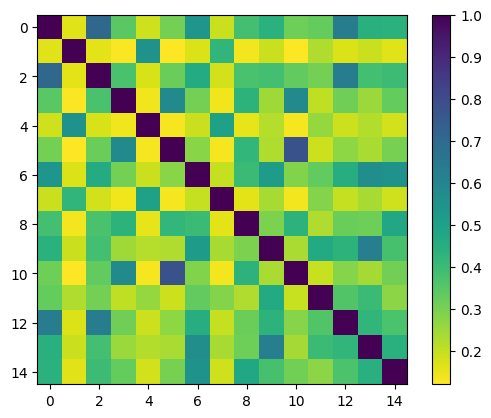

In [7]:
plt.imshow(similarity, cmap='viridis_r')
plt.colorbar()
# plt.show()

### Find molecules that are similar

In [10]:
# Get the values greater than 0.7
upper_mask = np.triu(np.ones_like(similarity, dtype=bool), k=1) # only care about upper triangle

# Apply mask and threshold
indices = np.where((similarity > 0.7) & upper_mask)
print(indices)

# Optional: as (row, col) pairs
pairs = list(zip(indices[0], indices[1]))

for p in pairs:
    print(f"Drug {drug_smiles[p[0]]} is similar to drug {drug_smiles[p[1]]}")


(array([0, 5]), array([ 2, 10]))
Drug CC(=O)OC1=CC=CC=C1C(=O)O is similar to drug CN1C=NC2=C1C(=O)N(C(=O)N2C)C
Drug CC1=CC(=O)NC(=O)N1 is similar to drug CC1=CC=CC=C1


# Visualize the molecules

In [11]:
import py3Dmol
from rdkit.Geometry import Point3D

In [12]:
def visualize_two_molecules(smi1, smi2):
    '''
    A function to visualize two molecules together
    '''
    # Create molecules
    mol1 = Chem.MolFromSmiles(smi1)  # ethanol
    mol2 = Chem.MolFromSmiles(smi2)  # ethylamine

    # Add hydrogens
    mol1 = Chem.AddHs(mol1)
    mol2 = Chem.AddHs(mol2)

    # Generate 3D conformers
    AllChem.EmbedMolecule(mol1)
    AllChem.EmbedMolecule(mol2)  # Now mol2 has a conformer

    # Translate mol2 by +5 angstrom along x-axis
    conf2 = mol2.GetConformer()  # This now works
    for i in range(mol2.GetNumAtoms()):
        pos = conf2.GetAtomPosition(i)
        conf2.SetAtomPosition(i, Point3D(pos.x + 8.0, pos.y, pos.z))

    # Convert to MolBlock
    mb1 = Chem.MolToMolBlock(mol1)
    mb2 = Chem.MolToMolBlock(mol2)

    # Viewer
    view = py3Dmol.view(width=400, height=400)
    view.addModel(mb1, 'mol')
    view.addModel(mb2, 'mol')
    view.setStyle({'stick': {}})
    view.zoomTo()
    view.show()


In [14]:
p = pairs[1]
visualize_two_molecules(drug_smiles[p[0]], drug_smiles[p[1]])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Your Task: Compare with fingerprint-based similarity Metrics